# 06 Prescription Recommendation Model (NLP)

## Objective
Build an NLP model to recommend drugs based on symptom text without using `src` modules.

## Pipeline
1. Tokenization with NLTK
2. TF-IDF vectorization
3. RandomForest classification
4. Accuracy and confusion matrix evaluation
5. Save trained model

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidate_roots if (p / 'data').exists()), None)
if project_root is None:
    raise FileNotFoundError('Could not locate data folder. Run from project root or notebooks folder.')

data_dir = project_root / 'data'
models_dir = project_root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

print(f'Project Root: {project_root}')
print(f'Data Directory: {data_dir}')

Project Root: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai
Data Directory: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai\data


In [2]:
prescriptions = pd.read_csv(data_dir / 'prescriptions.csv')
prescriptions['symptoms'] = prescriptions['symptoms'].astype(str)

print(f'Prescription dataset shape: {prescriptions.shape}')
print('\nSample data:')
display(prescriptions.head())

Prescription dataset shape: (1300, 4)

Sample data:


,patient_id,symptoms,drug_prescribed,date
0,PAT-32185,fever headache,Paracetamol,2023-01-01
1,PAT-20345,respiratory infection cough,Azithromycin,2023-01-02
2,PAT-20358,fever headache,Paracetamol,2023-01-03
3,PAT-71263,high cholesterol chest discomfort,Atorvastatin,2023-01-04
4,PAT-46010,mild pain blood thinning,Aspirin,2023-01-07


In [3]:
for resource in ['punkt', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

X = prescriptions['symptoms']
y = prescriptions['drug_prescribed']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline(
    steps=[
        ('tfidf', TfidfVectorizer(tokenizer=nltk.word_tokenize, lowercase=True, ngram_range=(1, 2))),
        ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced_subsample')),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

print('NLP Model Results:')
print(f'  Accuracy: {accuracy:.4f}')
print(f'  Test samples: {len(X_test)}')
print(f'  Classes: {len(sorted(y.unique()))}')

d:\projects\ai-ml-projects\PharmaEase_correct\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


NLP Model Results:
  Accuracy: 1.0000
  Test samples: 260
  Classes: 10


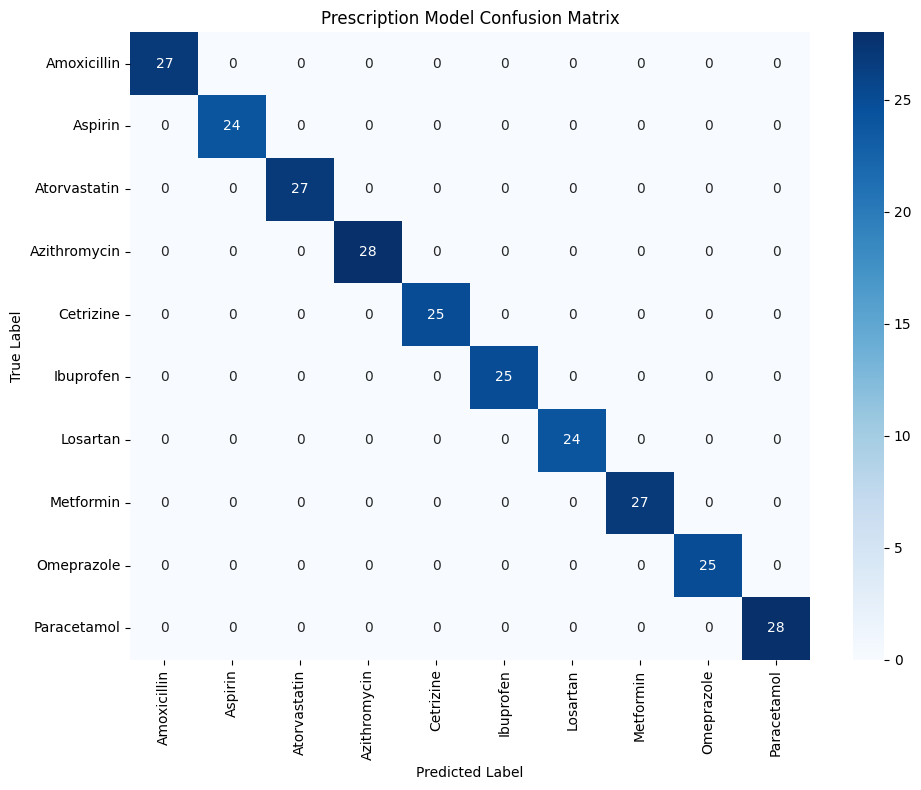

In [4]:
labels = sorted(prescriptions['drug_prescribed'].unique())
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('Prescription Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [5]:
def predict_drug(symptom_text: str) -> str:
    return str(model.predict([symptom_text])[0])

examples = [
    'high fever and headache',
    'acid reflux and stomach discomfort',
    'high blood pressure with dizziness',
    'allergy sneezing itchy eyes'
]

print('Prediction Examples:')
print('=' * 50)
for text in examples:
    pred = predict_drug(text)
    print(f'Symptoms: {text}')
    print(f'Recommended Drug: {pred}\n')

Prediction Examples:
Symptoms: high fever and headache
Recommended Drug: Paracetamol

Symptoms: acid reflux and stomach discomfort
Recommended Drug: Omeprazole

Symptoms: high blood pressure with dizziness
Recommended Drug: Losartan

Symptoms: allergy sneezing itchy eyes
Recommended Drug: Cetrizine



In [6]:
model_path = models_dir / 'prescription_model.pkl'
joblib.dump(model, model_path)
print(f'Saved model: {model_path.name}')

Saved model: prescription_model.pkl


## Model Insights

- TF-IDF converts symptom text into weighted numerical features.
- RandomForest handles non-linear patterns in symptom-drug mapping.
- Confusion matrix reveals where classes are mixed.
- Accuracy gives quick health check for recommendation quality.